**Goal:** answer L02's open question -- how do you *choose* k? -- with the honest
machinery: diagnose overfitting and underfitting from train-vs-validation scores,
then pick hyperparameters by cross-validation while the test set stays sealed.
Pairs with the concept note
[The Bias-Variance Dilemma and Cross-Validation](l09_concept_bias_variance_cv.qmd).

> **Previously:** L08 -- Support Vector Machines  |  **Next:** L10 -- Regularization & Model/Feature Selection

> This page is the read-only view. To run the lab, open the notebook
> (`l09_lab_bias_variance_cv.ipynb`) -- in Colab via the badge on the concept page,
> or locally.

## Scenario

Back in L02 you swept k = 1, 15, 51 on the coqui calls, saw the middle value win,
and were promised a principled treatment "in Unit III". This is Unit III. Same
data, same split -- but this time the choice will be made *without ever touching
the test set*, and you will see exactly what goes wrong when people cheat.

## Setup

The setup is **two cells** (the pattern every lab uses). Run them top to bottom. The
first only installs; the second imports, seeds the random number generator, and
builds the data -- so when you re-run imports while experimenting, you do not
re-install.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, numpy, pandas and matplotlib, so this is effectively a no-op there.
%pip install -q scikit-learn
# local, in a terminal (not in the notebook):  uv add scikit-learn numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, DATA (safe to re-run without re-installing)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)          # the L02 generator, verbatim
n = 150                                  # calls per species

calls = pd.DataFrame({
    "co_khz":  np.concatenate([rng.normal(1.15, 0.18, n), rng.normal(1.45, 0.18, n)]),
    "qui_khz": np.concatenate([rng.normal(2.05, 0.25, n), rng.normal(2.45, 0.25, n)]),
    "species": ["coqui"] * n + ["portoricensis"] * n,
})

from sklearn.model_selection import train_test_split

X = calls[["co_khz", "qui_khz"]]
y = calls["species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=11, stratify=y)
print(len(X_train), "training calls /", len(X_test), "test calls")

225 training calls / 75 test calls


~~~text
225 training calls / 75 test calls
~~~

From here on, pretend the 75 test calls are in a sealed envelope. We will open it
exactly once, at the very end.

## Step 1: The Flexibility Spectrum

### Naive approach: judge models by their training score

In [3]:
from sklearn.neighbors import KNeighborsClassifier

for k in (1, 25):
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    print(f"k={k}: training accuracy {model.score(X_train, y_train):.3f}")

k=1: training accuracy 1.000
k=25: training accuracy 0.831


~~~text
k=1: training accuracy 1.000
k=25: training accuracy 0.831
~~~

By training accuracy, k=1 is *perfect*. Of course it is: with one neighbor, every
training call's nearest neighbor is itself -- the model is an answer key for data
it has already seen. The training score measures memorization, not learning.

### Better approach: judge models by cross-validation

5-fold cross-validation grades each k on data the model did *not* fit -- five
times over, inside the training set, with the envelope still sealed:

In [4]:
from sklearn.model_selection import cross_val_score

ks = [1, 3, 5, 9, 15, 25, 45, 75, 115, 165]
rows = []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    # cv=5: five stratified folds (sklearn's default fold strategy for classifiers)
    cv_scores = cross_val_score(KNeighborsClassifier(n_neighbors=k),
                                X_train, y_train, cv=5)
    rows.append({"k": k, "train_acc": model.score(X_train, y_train),
                 "cv_acc": cv_scores.mean()})
sweep = pd.DataFrame(rows).round(3)
print(sweep.to_string(index=False))

  k  train_acc  cv_acc
  1      1.000   0.800
  3      0.898   0.849
  5      0.884   0.849
  9      0.884   0.840
 15      0.871   0.840
 25      0.831   0.849
 45      0.849   0.844
 75      0.836   0.840
115      0.836   0.844
165      0.849   0.840


~~~text
  k  train_acc  cv_acc
  1      1.000   0.800
  3      0.898   0.849
  5      0.884   0.849
  9      0.884   0.840
 15      0.871   0.840
 25      0.831   0.849
 45      0.849   0.844
 75      0.836   0.840
115      0.836   0.844
165      0.849   0.840
~~~

(One practical limit baked into the grid: with 225 training calls, each CV round
trains on 180 -- so k cannot exceed 180, and we stop at 165.)

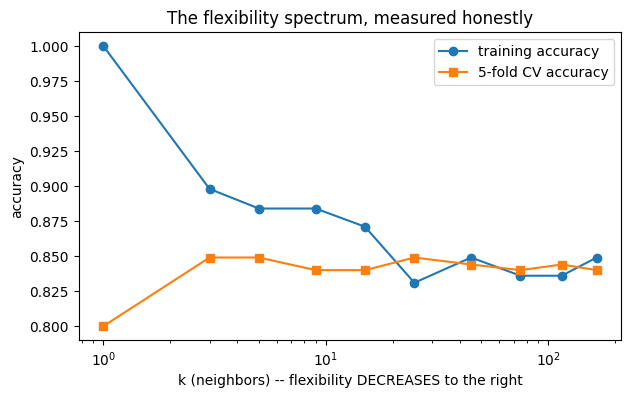

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep["k"], sweep["train_acc"], marker="o", label="training accuracy")
ax.plot(sweep["k"], sweep["cv_acc"], marker="s", label="5-fold CV accuracy")
ax.set_xscale("log")
ax.set_xlabel("k (neighbors) -- flexibility DECREASES to the right")
ax.set_ylabel("accuracy")
ax.legend()
ax.set_title("The flexibility spectrum, measured honestly")
plt.show()

Read the picture against the concept note's diagnosis table. At k=1 (maximum
flexibility) the two curves are 0.200 apart -- a textbook **overfit**: huge
generalization gap. Moving right, the gap closes; by k=45 and beyond the curves
have converged into a plateau around 0.84 -- the model is now so rigid that it
cannot do better, the gentle form of **underfitting** this easy dataset allows.
The CV curve's best neighborhood is small k (3-5): that is the sweet spot between
the cliff on the left and the plateau on the right.

## Step 2: Choosing k -- the Trap, Then the Protocol

The tempting shortcut is to sweep k against the *test* set and pick the winner.
Run it once, labeled for what it is, so you recognize it in the wild:

In [6]:
# THE TEMPTING WRONG WAY -- shown so you can recognize it, never to imitate:
test_accs = [KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train).score(X_test, y_test)
             for k in ks]
k_peek = ks[int(np.argmax(test_accs))]
print(f"test-peeking would choose k={k_peek} and report {max(test_accs):.3f}")

test-peeking would choose k=9 and report 0.867


~~~text
test-peeking would choose k=9 and report 0.867
~~~

0.867 beats everything in our CV table -- and it is not a real result. The test
set just *voted on the model*: out of ten candidates we kept the one that happened
to flatter these particular 75 calls, so 0.867 is part luck, and the envelope is
no longer sealed. There is no honest number left to report.

Now the real protocol -- pick by CV, refit, open the envelope once. Complete the
marked lines:

In [7]:
# Uncomment and complete the marked lines:
# best_k = int(sweep.loc[sweep[____].idxmax(), "k"])    # pick by the CV column -- never by test
# print(f"cross-validation chooses k={best_k} (CV accuracy {sweep['cv_acc'].max():.3f})")
# final = KNeighborsClassifier(n_neighbors=best_k).fit(____, ____)     # refit on ALL training data
# print(f"final honest test accuracy: {final.score(____, ____):.3f}")  # the envelope, opened ONCE

<details><summary>Expected Output</summary>

~~~text
cross-validation chooses k=3 (CV accuracy 0.849)
final honest test accuracy: 0.840
~~~

The honest report: **k=3, expected accuracy about 0.84**. Yes, it is lower than
the trap's 0.867 -- that is the point. The trap's number was inflated by letting
the test set choose; this one is a fair forecast of performance on calls nobody
has seen. A lower number you can trust beats a higher number you cannot. (L02's
sweep was on the right track: of its three candidates, the small-middle one won
here too.)
</details>

## Your Turn

### Exercise 1 -- Settle L08's gamma, properly

L08 caught gamma=100 overfitting the kayak pings -- but we caught it by looking at
the test set, which we now know is cheating. Redo it right: choose gamma from
{0.1, 1, 10, 100} by cross-validation only, then report one final test score.

**Hint:** `cross_val_score(SVC(kernel="rbf", gamma=g), Xp_train, yp_train, cv=5).mean()` for each gamma; then fit the winner and score the test set once.

In [8]:
from sklearn.svm import SVC
from sklearn.datasets import make_moons

raw_xy, raw_label = make_moons(n_samples=300, noise=0.2, random_state=11)
pings = pd.DataFrame(raw_xy.round(3), columns=["east_km", "north_km"])
pings["operator"] = np.where(raw_label == 0, "bahia_glow", "luna_azul")
Xp = pings[["east_km", "north_km"]]
yp = pings["operator"]
Xp_train, Xp_test, yp_train, yp_test = train_test_split(Xp, yp, test_size=0.25,
                                                        random_state=11, stratify=yp)

# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
gamma=0.1: CV accuracy 0.884
gamma=1: CV accuracy 0.960
gamma=10: CV accuracy 0.947
gamma=100: CV accuracy 0.924
chosen gamma=1; final test accuracy: 0.893
~~~

Cross-validation ranks gamma=100 third -- it never needed the test set to smell
the overfit, because the gamma=100 model also fails on held-out *folds*. The
chosen gamma=1 then earns 0.893 on the still-sealed test set: the same verdict
L08 reached by peeking, reached cleanly this time.
</details>

### Exercise 2 -- How lucky is one split?

The CV accuracy 0.849 for k=3 is an *average* of five rehearsals. Print the five
individual fold scores. If you had used a single validation split instead, what
range of stories might you have been told?

**Hint:** `cross_val_score(...)` returns the 5 individual fold scores -- print the array itself, not just its mean.

In [9]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
fold scores: [0.822 0.889 0.889 0.911 0.733]
mean 0.849, spread (max - min) 0.178
~~~

Depending on which slice of data played validator, a single split would have
reported anything from a grim 0.733 to a glowing 0.911 -- a spread of 0.178 for
the *same model*. That lottery is exactly why we rotate through five folds and
average: the mean is a far steadier estimate than any one rehearsal.
</details>

## Summary

- The training score rewards memorization: k=1 scored a perfect 1.000 while
  cross-validation exposed it as the *worst* candidate (0.800).
- Diagnose by the pair: big train-vs-validation gap = overfit (the left cliff);
  both converged at a mediocre level = underfit (the right plateau); the sweet
  spot lives between.
- The test set is a sealed envelope, opened once: tuning on it produced a number
  (0.867) that is part luck and wholly unreportable; the honest protocol --
  choose by CV, refit, test once -- reported 0.840.
- One validation split is a lottery (fold scores ranged 0.733 to 0.911);
  averaging five folds is what makes the estimate steady.
- Next (L10): cross-validation tells you *when* a model is too flexible --
  regularization gives the model a built-in dial to fix it.